<a href="https://colab.research.google.com/github/ShiftorTheOrca/asah-capstone/blob/nelson/asah_fetch_a25_cs328.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Import Library**


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder

from yellowbrick.cluster import KElbowVisualizer

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

import os
import shutil
import joblib

# **Data Loading**


In [2]:
from google.colab import files
files.upload()
print("API Key Received")

Saving kaggle.json to kaggle (9).json
API Key Received


In [3]:
os.makedirs('/root/.kaggle', exist_ok=True)

# Download dataset dari Kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!kaggle datasets download -d mashlyn/online-retail-ii-uci
!unzip online-retail-ii-uci.zip

Dataset URL: https://www.kaggle.com/datasets/mashlyn/online-retail-ii-uci
License(s): CC0-1.0
online-retail-ii-uci.zip: Skipping, found more recently modified local copy (use --force to force download)
Archive:  online-retail-ii-uci.zip
replace online_retail_II.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: online_retail_II.csv    


In [4]:
# Membuat path directory
df = pd.read_csv("online_retail_II.csv")
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1067371 non-null  object 
 1   StockCode    1067371 non-null  object 
 2   Description  1062989 non-null  object 
 3   Quantity     1067371 non-null  int64  
 4   InvoiceDate  1067371 non-null  object 
 5   Price        1067371 non-null  float64
 6   Customer ID  824364 non-null   float64
 7   Country      1067371 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 65.1+ MB


In [6]:
df.describe(include="all")

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
count,1067371,1067371,1062989,1.067371e+06,1067371,1.067371e+06,824364.000000,1067371
unique,53628,5305,5698,NaN,47635,NaN,NaN,43
top,537434,85123A,WHITE HANGING HEART T-LIGHT HOLDER,NaN,2010-12-06 16:57:00,NaN,NaN,United Kingdom
freq,1350,5829,5918,NaN,1350,NaN,NaN,981330
mean,NaN,NaN,NaN,9.938898e+00,NaN,4.649388e+00,15324.638504,NaN
std,NaN,NaN,NaN,1.727058e+02,NaN,1.235531e+02,1697.464450,NaN
min,NaN,NaN,NaN,-8.099500e+04,NaN,-5.359436e+04,12346.000000,NaN
25%,NaN,NaN,NaN,1.000000e+00,NaN,1.250000e+00,13975.000000,NaN
50%,NaN,NaN,NaN,3.000000e+00,NaN,2.100000e+00,15255.000000,NaN
75%,NaN,NaN,NaN,1.000000e+01,NaN,4.150000e+00,16797.000000,NaN


In [7]:
df.isnull().sum()

,0
Invoice,0
StockCode,0
Description,4382
Quantity,0
InvoiceDate,0
Price,0
Customer ID,243007
Country,0


In [8]:
df.dropna(inplace=True)
df.isnull().sum()

,0
Invoice,0
StockCode,0
Description,0
Quantity,0
InvoiceDate,0
Price,0
Customer ID,0
Country,0


In [9]:
df.duplicated().sum()

np.int64(26479)

In [10]:
df.drop_duplicates(inplace=True)
df.duplicated().sum()

np.int64(0)

In [11]:
numerical_cols = df.drop("Customer ID", axis=1).select_dtypes(include=[np.number]).columns
categorical_cols = df.select_dtypes(include="object").columns

In [12]:
Q1 = df[numerical_cols].quantile(0.25)
Q3 = df[numerical_cols].quantile(0.75)
IQR = Q3 - Q1

condition = ~((df[numerical_cols] < (Q1 - 1.5 * IQR)) | (df[numerical_cols] > (Q3 + 1.5 * IQR))).any(axis=1)

df = df[condition]

df.describe(include="all")

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
count,676146,676146,676146,676146.000000,676146,676146.000000,676146.000000,676146
unique,38974,4279,4859,NaN,36409,NaN,NaN,41
top,576339,85123A,WHITE HANGING HEART T-LIGHT HOLDER,NaN,2011-11-14 15:27:00,NaN,NaN,United Kingdom
freq,460,4165,4159,NaN,460,NaN,NaN,614056
mean,NaN,NaN,NaN,7.191781,NaN,2.287133,15343.657274,NaN
std,NaN,NaN,NaN,6.823136,NaN,1.615757,1694.313973,NaN
min,NaN,NaN,NaN,-13.000000,NaN,0.000000,12346.000000,NaN
25%,NaN,NaN,NaN,2.000000,NaN,1.250000,13988.000000,NaN
50%,NaN,NaN,NaN,5.000000,NaN,1.690000,15301.000000,NaN
75%,NaN,NaN,NaN,12.000000,NaN,2.950000,16813.000000,NaN


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 676146 entries, 0 to 1067369
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Invoice      676146 non-null  object 
 1   StockCode    676146 non-null  object 
 2   Description  676146 non-null  object 
 3   Quantity     676146 non-null  int64  
 4   InvoiceDate  676146 non-null  object 
 5   Price        676146 non-null  float64
 6   Customer ID  676146 non-null  float64
 7   Country      676146 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 46.4+ MB


In [14]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
5,489434,22064,PINK DOUGHNUT TRINKET POT,24,2009-12-01 07:45:00,1.65,13085.0,United Kingdom


## **Exploratory Data Analysis (EDA)**

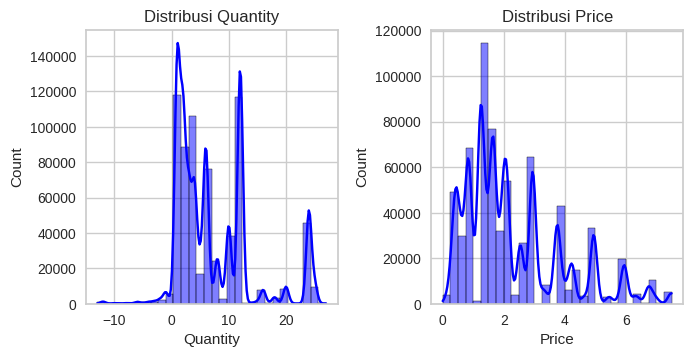

In [15]:
# Distribusi fitur numerik
plt.figure(figsize=(14, 10))
for i, column in enumerate(numerical_cols, 1):
    plt.subplot(3, 4, i)
    sns.histplot(df[column], bins=30, kde=True, color='blue')
    plt.title(f'Distribusi {column}')
plt.tight_layout()
plt.show()

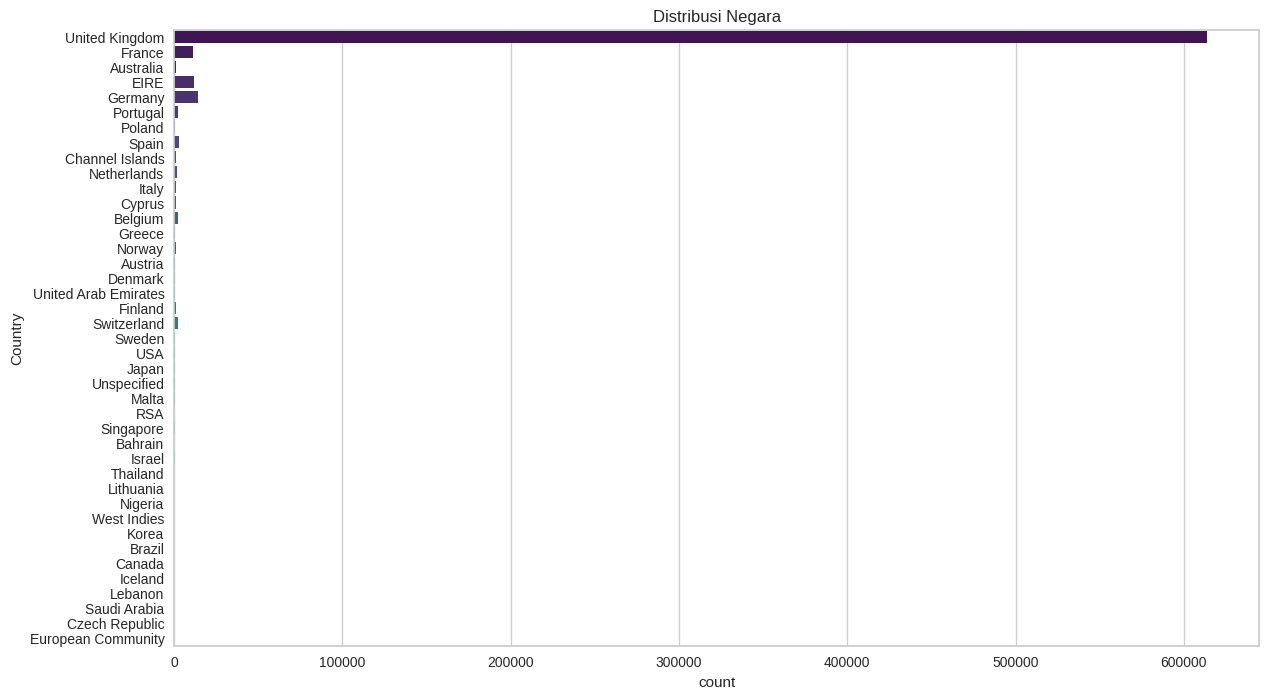

In [16]:
# Distribusi fitur Negara
plt.figure(figsize=(14, 8))
sns.countplot(data=df, y="Country", hue="Country", palette='viridis', legend=False)
plt.title(f'Distribusi Negara')
plt.show()

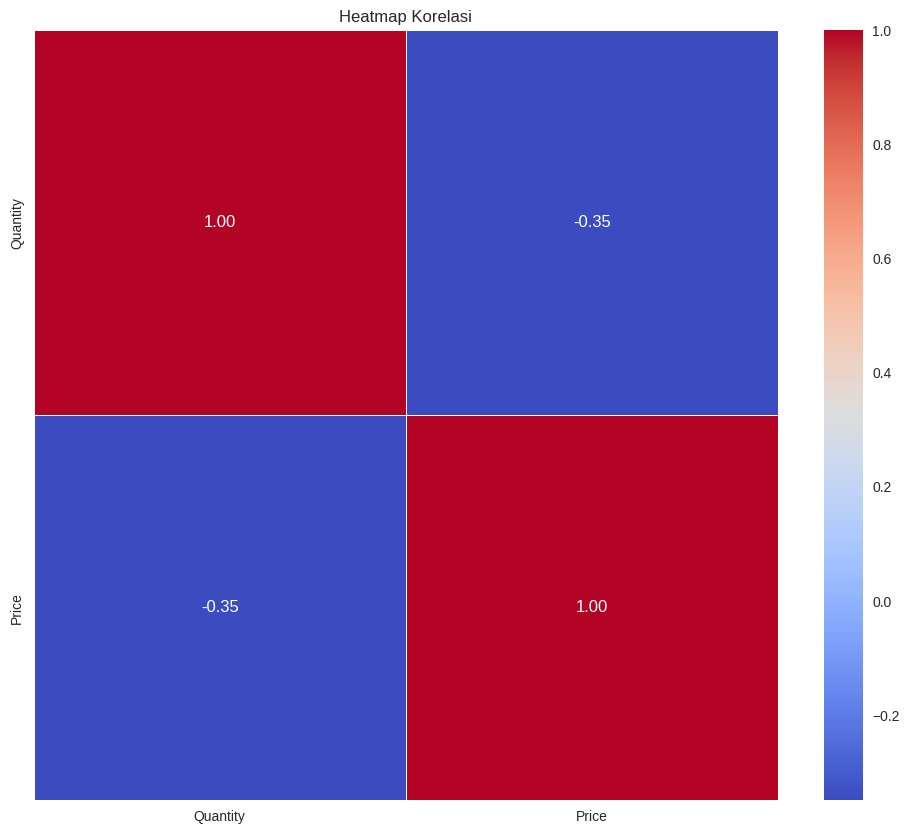

In [17]:
# Heatmap korelasi untuk fitur numerik
plt.figure(figsize=(12, 10))
correlation_matrix = df[numerical_cols].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Heatmap Korelasi')
plt.show()

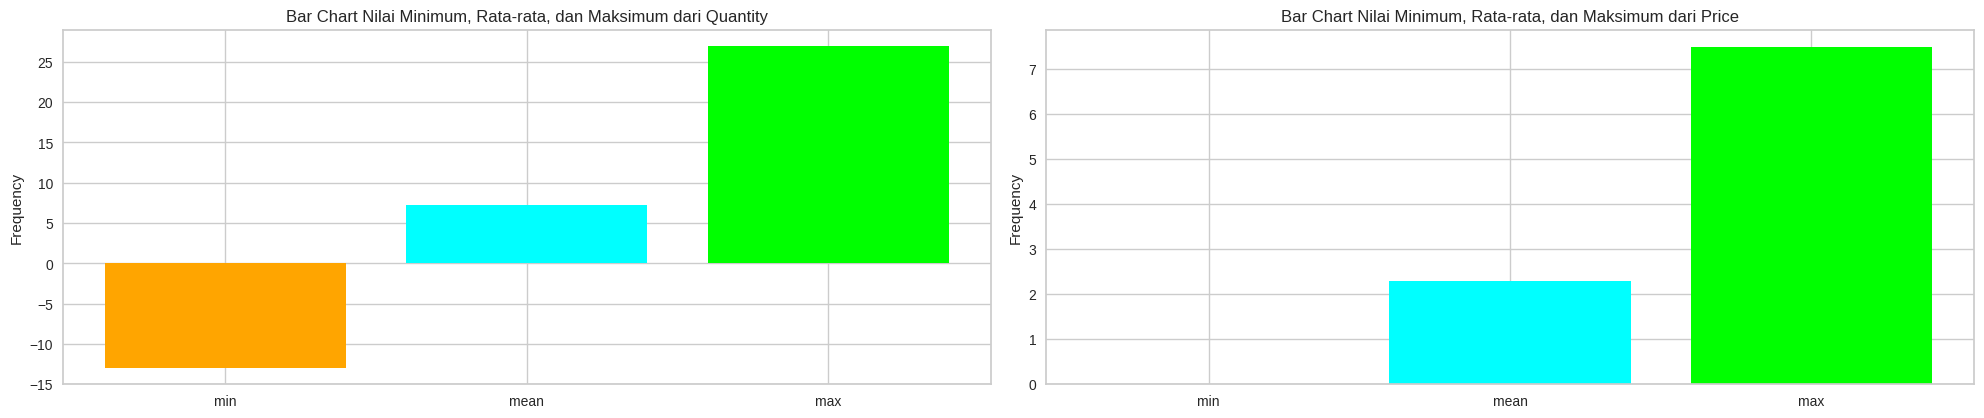

In [18]:
n_cols = 2
num_vars = df.shape[1]
n_rows = -(-num_vars // n_cols)


fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 4))

axes = axes.flatten()

mean_vals = df[numerical_cols].mean()
min_vals = df[numerical_cols].min()
max_vals = df[numerical_cols].max()

for i, column in enumerate(df[numerical_cols]):
    stats = df[column].agg(['min','mean','max'])
    axes[i].bar(stats.index, stats.values, color=['orange','cyan','lime'])
    axes[i].set_title(f"Bar Chart Nilai Minimum, Rata-rata, dan Maksimum dari {column}")
    axes[i].set_ylabel('Frequency')

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# **Preprocessing**